# Cell type classification.

## Preparing the notebook.

### Flags for autoreloading.

In [1]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Autoreloading the notebook.

In [90]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

### Importing the libraries.

In [91]:
import sys

import numpy as np
import scanpy as sc
from sklearn.model_selection import ShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import torch

from sc_exp_design.models import TargetPredictionModel
from sc_exp_design.training.callbacks import MetricsCallBack, TrainingCallBacks

sys.path.insert(0, "../../../scripts")
from data_utils import apply_shared_transformations


### Constants.

In [92]:
H5AD_PATH = "../../../../gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"

K = 3
TEST_SIZE = 0.3
RANDOM_STATE = 42

SCATTER_COLUMNS = ["FSC - Area", "FSC - Height", "FSC - Width", "SSC - Area", "SSC - Height", "SSC - Width"]

SAMPLE_REP = "X_channel_standardized+X_scatter_standardized"
TARGET_COVARIATES = {"cell_type": "label"}


## Data.

### Loading Anndata To memory.

In [5]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Splitting the data.

In [6]:
skf = ShuffleSplit(n_splits=K, test_size=TEST_SIZE, random_state=RANDOM_STATE)
splits = skf.split(np.zeros(len(adata)), adata.obs["cell_type"].values)
(train_index, test_index) = next(iter(splits))
train_adata = adata[train_index]
val_adata = adata[test_index]
val_adata_dict = {"test0": val_adata}
train_adata, val_adata_dict


(View of AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
     obsm: 'X_pca', 'X_umap'
     layers: 'positives

### Applying Shared tranformation to train and ood data.

In [8]:
train_adata, ood_adata_dict = apply_shared_transformations(adata, val_adata_dict, SCATTER_COLUMNS)
train_adata, ood_adata_dict

/ictstr01/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/cell_type_classification/notebooks/examples/../../../scripts/data_utils.py:199: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  ood_adata.obsm["X_pca"] = np.einsum("...d,dk -> ...k", ood_adata.X, train_adata.varm["PCs"])


(AnnData object with n_obs × n_vars = 100000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'pca', 'X_scatter_params', 'X_channel_params'
     obsm: '

## Model.

### Initializing classifier.

In [93]:
classifier = TargetPredictionModel()

### Preparing the data for the model.

In [94]:
classifier.prepare_train_data(
    train_adata,
    sample_rep=SAMPLE_REP,
    target_covariates=TARGET_COVARIATES,
)
classifier.prepare_validation_data(next(iter(ood_adata_dict.values())))

### Preparing the model.

In [95]:
classifier.prepare_model(
    target_covariates=("cell_type",),
    target_covariates_dims={"cell_type": adata.obs.cell_type.nunique()},
    target_covariates_use_shared_representation=True,
    target_covariates_encoder_mlp_kwargs={
        "hidden_dims": (32, 32),
        "activation_class": torch.nn.ReLU,
        "final_activation_class": torch.nn.Identity,
        "use_batchnorm": False,
        "use_dropout": False,
    },
    target_covariates_predictor_kwargs={
        "cell_type": {
            "hidden_dims": (),
            "activation_class": torch.nn.Identity,
            "final_activation_class": torch.nn.Identity,
            "use_batchnorm": False,
            "use_dropout": False,
        }
    }
)

### Preparing the callbacks.

In [96]:
metrics_cb = MetricsCallBack(
    metric_ids=[
        "accuracy",
        "micro_precision",
        "micro_f1_score",
        "micro_recall",

        "macro_precision",
        "macro_f1_score",
        "macro_recall",

        "weighted_precision",
        "weighted_f1_score",
        "weighted_recall",

        "micro_roc_auc",
        "macro_roc_auc",
    ]
)
cb = TrainingCallBacks((metrics_cb, ))

### Computing class weights.

In [97]:
values = train_adata.obs["cell_type"].values
classes = np.unique(values)
class_weights = torch.from_numpy(compute_class_weight("balanced", classes=np.unique(train_adata.obs["cell_type"].values), y=train_adata.obs["cell_type"].values)).float().to("cuda")


### Training the model.

  0%|          | 1/500 [00:00<03:44,  2.22it/s]/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Loss: 0.2922: 100%|██████████| 500/500 [00:29<00:00, 16.70it/s]


(<Figure size 4200x300 with 14 Axes>,
 array([<Axes: title={'center': 'loss'}>,
        <Axes: title={'center': 'cell_type_pert_posterior_loss'}>,
        <Axes: title={'center': 'cell_type_accuracy'}>,
        <Axes: title={'center': 'cell_type_micro_precision'}>,
        <Axes: title={'center': 'cell_type_micro_f1_score'}>,
        <Axes: title={'center': 'cell_type_micro_recall'}>,
        <Axes: title={'center': 'cell_type_macro_precision'}>,
        <Axes: title={'center': 'cell_type_macro_f1_score'}>,
        <Axes: title={'center': 'cell_type_macro_recall'}>,
        <Axes: title={'center': 'cell_type_weighted_precision'}>,
        <Axes: title={'center': 'cell_type_weighted_f1_score'}>,
        <Axes: title={'center': 'cell_type_weighted_recall'}>,
        <Axes: title={'center': 'cell_type_micro_roc_auc'}>,
        <Axes: title={'center': 'cell_type_macro_roc_auc'}>], dtype=object))

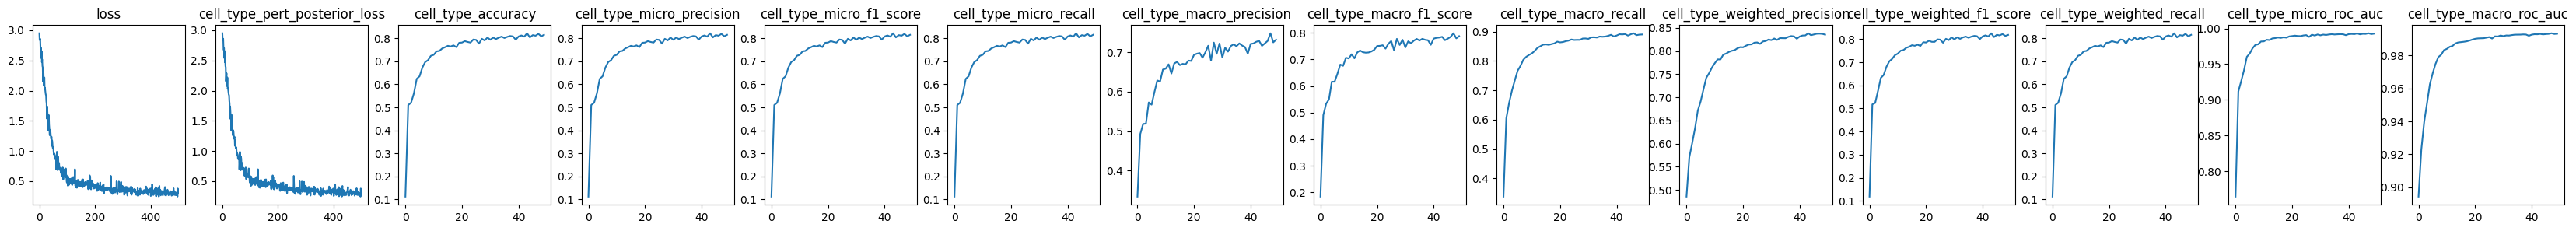

In [98]:
classifier.train_target_prediction_model(
    num_training_steps=500,
    valid_freq=10,
    train_batch_size=1024,
    validation_batch_size=512,
    state_transforms=None,
    callbacks=cb,
    grad_steps_log_interval=100,
    loss_fn_kwargs={"weight":class_weights}
)
keys = list(classifier.target_predictor_trainer.training_logs.keys())
classifier.target_predictor_trainer.plot_training_logs(figsize=(len(keys)*3, 3), keys_to_plot=keys)